# E-commerce SQL Analytics

Answering real business questions about an online store **with SQL**, against a
normalised SQLite database.

The schema is a small star: `customers`, `products`, `orders`, `order_items`
(built by [`data/build_db.py`](../data/build_db.py)). Reusable queries live in the
[`sql/`](../sql) folder; this notebook runs them and visualises the answers.

**SQL features demonstrated:** multi-table JOINs, aggregation & GROUP BY, CTEs,
window functions (`RANK`, `SUM() OVER`), conditional aggregation and date bucketing.


In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
conn = sqlite3.connect("../data/ecommerce.db")

def run(name):
    """Run a saved .sql file and return a DataFrame."""
    sql = Path(f"../sql/{name}").read_text()
    return pd.read_sql_query(sql, conn)

# tables overview
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)

,name
0,customers
1,order_items
2,orders
3,products


## The schema

```
customers (customer_id PK, name, country, signup_date)
products  (product_id PK, product_name, category, price)
orders    (order_id PK, customer_id FK, order_date, status)
order_items (order_item_id PK, order_id FK, product_id FK, quantity, unit_price)
```
Revenue = `SUM(order_items.quantity * order_items.unit_price)` over `completed` orders.

## Q1 — How is monthly revenue trending?

,month,orders,revenue
0,2023-01,127,72906.10
1,2023-02,97,52198.95
2,2023-03,106,65241.46
3,2023-04,110,72295.20
4,2023-05,103,64206.99


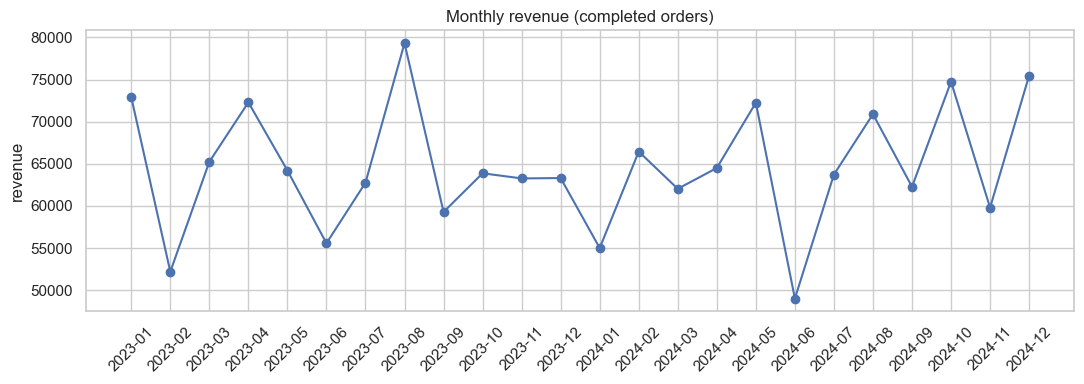

In [2]:
rev = run("01_monthly_revenue.sql")
display(rev.head())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rev["month"], rev["revenue"], marker="o")
ax.set_title("Monthly revenue (completed orders)"); ax.set_ylabel("revenue")
ax.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

## Q2 — Who are our most valuable customers?

In [3]:
run("02_top_customers.sql")

,rank,name,country,orders,lifetime_value
0,1,Max Rossi,France,32,21379.06
1,2,Lena Rossi,Netherlands,28,19669.19
2,3,Noah Dubois,Spain,35,19465.69
3,4,Sara Dubois,Belgium,24,16156.16
4,5,Sofia Rossi,Belgium,22,15953.74
5,6,Noah Janssens,France,14,13597.32
6,7,Max Peeters,Germany,22,13402.70
7,8,Anna Müller,Germany,22,13168.17
8,9,Lucas Bernard,Belgium,17,12605.68
9,10,Hugo Müller,Italy,23,12285.53


Uses a CTE to compute per-customer lifetime value, then a `RANK()` window function
to order them — a classic pattern for leaderboards / VIP segmentation.

## Q3 — Which product categories drive revenue?

,category,units_sold,revenue,pct_of_revenue
0,Electronics,2534,895860.06,57.8
1,Sports,2355,303982.91,19.6
2,Home,2793,163968.98,10.6
3,Beauty,2134,108803.70,7.0
4,Books,2971,77798.38,5.0


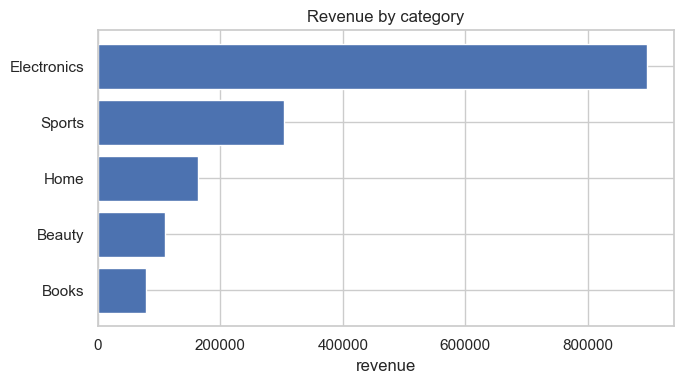

In [4]:
cat = run("03_category_performance.sql")
display(cat)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(cat["category"], cat["revenue"], color="#4C72B0")
ax.invert_yaxis(); ax.set_title("Revenue by category"); ax.set_xlabel("revenue")
plt.tight_layout(); plt.show()

## Q4 — How do markets compare?

,country,customers,orders,revenue,avg_order_value
0,Belgium,95,608,370580.27,609.51
1,France,84,580,345927.05,596.43
2,Germany,68,491,285984.13,582.45
3,Netherlands,59,462,280760.82,607.71
4,Spain,35,255,153556.39,602.18
5,Italy,31,195,113605.37,582.59


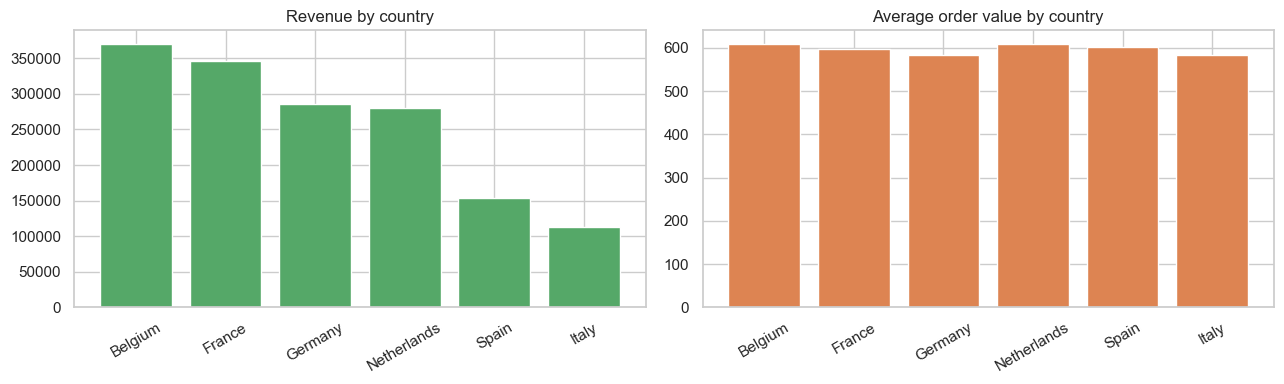

In [5]:
country = run("04_revenue_by_country.sql")
display(country)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(country["country"], country["revenue"], color="#55A868")
axes[0].set_title("Revenue by country"); axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(country["country"], country["avg_order_value"], color="#DD8452")
axes[1].set_title("Average order value by country")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## Q5 — How loyal are our customers?

In [6]:
run("05_repeat_purchase_rate.sql")

,active_customers,repeat_customers,repeat_rate_pct
0,372,342,91.9


A high repeat-purchase rate (computed with conditional aggregation in a single pass)
indicates strong retention — a key e-commerce health metric.

## Q6 — Cumulative growth

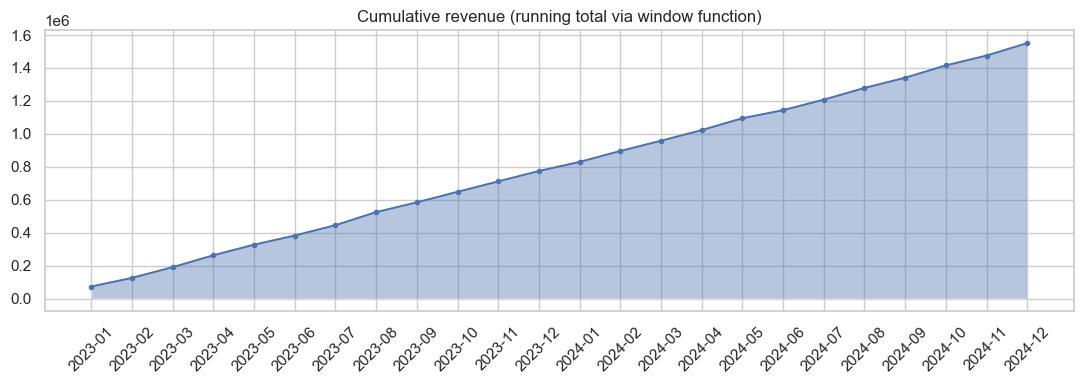

In [7]:
cum = run("06_running_monthly_revenue.sql")

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(cum["month"], cum["cumulative_revenue"], alpha=0.4)
ax.plot(cum["month"], cum["cumulative_revenue"], marker=".")
ax.set_title("Cumulative revenue (running total via window function)")
ax.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

## Ad-hoc query: order status mix

Not every analysis needs a saved file — quick exploratory SQL inline:

In [8]:
pd.read_sql_query('''
    SELECT status,
           COUNT(*) AS orders,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM orders), 1) AS pct
    FROM orders
    GROUP BY status
    ORDER BY orders DESC
''', conn)

,status,orders,pct
0,completed,2591,86.4
1,returned,268,8.9
2,cancelled,141,4.7


In [9]:
conn.close()

## Summary

Answered six business questions purely in SQL — revenue trends, customer value,
category and market performance, loyalty and cumulative growth — using JOINs, CTEs,
window functions and conditional aggregation.

**Extensions:** cohort/retention analysis with date arithmetic, RFM segmentation,
month-over-month growth with `LAG()`, and packaging the queries behind a small
reporting view.